Epoch 1/10, Loss: 16.029588, Alpha: 0.004303454887121916, Beta: 0.004303454887121916
Epoch 2/10, Loss: 16.001513, Alpha: 0.0001851972338045016, Beta: 0.0001851972338045016
Epoch 3/10, Loss: 15.990896, Alpha: 7.969874786795117e-06, Beta: 7.969874786795117e-06
Epoch 4/10, Loss: 15.981573, Alpha: 3.4297988804610213e-07, Beta: 3.4297988804610213e-07
Epoch 5/10, Loss: 15.966962, Alpha: 1.475998967492842e-08, Beta: 1.475998967492842e-08
Epoch 6/10, Loss: 15.954442, Alpha: 6.351894565881366e-10, Beta: 6.351894565881366e-10
Epoch 7/10, Loss: 15.940499, Alpha: 2.7335063032540852e-11, Beta: 2.7335063032540852e-11
Epoch 8/10, Loss: 15.928925, Alpha: 1.1763518761517822e-12, Beta: 1.1763518761517822e-12
Epoch 9/10, Loss: 15.915843, Alpha: 5.0623805006918404e-14, Beta: 5.0623805006918404e-14
Epoch 10/10, Loss: 15.904856, Alpha: 2.178572551986323e-15, Beta: 2.178572551986323e-15
Average BER: 0.499972


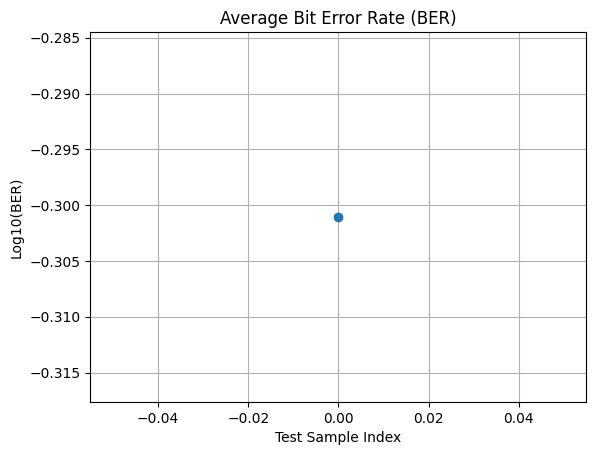

In [19]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Import Sionna modules for channel modeling
from sionna.phy.channel.rayleigh_block_fading import RayleighBlockFading
from sionna.phy.utils import ebnodb2no

# Set random seeds for reproducibility
np.random.seed(1)
tf.random.set_seed(1)

class Generator:
    def __init__(self, M, N, L, chunk_size=1000):
        self.M = M  
        self.N = N  
        self.L = L  
        self.chunk_size = chunk_size
        # CORRECTED: Configure for 1 TX (M antennas) and 1 RX (N antennas)
        self.channel = RayleighBlockFading(num_tx=1, num_tx_ant=M,
                                          num_rx=1, num_rx_ant=N)

    def generate(self, snr_db):
        x = np.sign(np.random.uniform(-1, 1, (self.M, self.L)))
        H_chunks = []
        total_steps = self.L
        num_full_chunks = total_steps // self.chunk_size
        
        for _ in range(num_full_chunks):
            # CORRECTED: Get channel matrix (first element of tuple)
            H_batch, _ = self.channel(batch_size=1, num_time_steps=self.chunk_size)
            # Convert TensorFlow tensor to numpy and squeeze dimensions
            H_batch = H_batch.numpy()
            # Remove batch(0), rx(1), tx(3), and paths(5) dimensions
            H_chunk = np.squeeze(H_batch, axis=(0, 1, 3, 5))
            H_chunks.append(H_chunk)  # Now shape (N, M, chunk_size)
        
        remaining_steps = total_steps % self.chunk_size
        if remaining_steps:
            H_batch, _ = self.channel(batch_size=1, num_time_steps=remaining_steps)
            H_batch = H_batch.numpy()
            H_chunk = np.squeeze(H_batch, axis=(0, 1, 3, 5))
            H_chunks.append(H_chunk)
        
        H = np.concatenate(H_chunks, axis=-1)  # Shape (N, M, L)
        
        # Rest of the noise calculation and y generation remains the same
        noise_var = ebnodb2no(snr_db, self.N, self.M)
        noise = np.sqrt(noise_var / 2) * (
            np.random.normal(size=(self.N, self.L)) +
            1j * np.random.normal(size=(self.N, self.L))
        )
        y = np.einsum('nmt,mt->nt', H, x) + noise
        
        return x, H, np.real(y)

def create_mlp_model(input_dim, output_dim, hidden_units, activation):
    """
    Constructs a simple Keras-based MLP model.
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(input_dim,)))
    for units in hidden_units:
        model.add(tf.keras.layers.Dense(units, activation=activation))
    # Final dense layer with linear activation
    model.add(tf.keras.layers.Dense(output_dim))
    return model

# Define the parameters
M = 32      # Number of transmit antennas (input dimension)
N = 64      # Number of receive antennas (output dimension)
L = 10000   # Total number of symbols (time steps)
snr_db = 30 # Example SNR in dB

# Create the data generator instance with a chosen chunk size (e.g., 1000)
generator = Generator(M, N, L, chunk_size=10)  # Changed from 1000 to 10
# Generate training data
x_train, H_train, y_train = generator.generate(snr_db)

# Reshape training data so that each sample (time step) is a row.
# Original shapes: x_train = (M, L) and y_train = (N, L)
x_train_reshaped = x_train.T  # Now shape becomes (L, M)
y_train_reshaped = y_train.T  # Now shape becomes (L, N)

# Create the Keras-based MLP model.
model = create_mlp_model(input_dim=M, output_dim=N, hidden_units=[64, 32], activation='relu')
model.compile(optimizer='adam', loss='mean_squared_error')

# Training parameters
num_epochs = 10
batch_size = 32

# Initialize auxiliary variables alpha and beta
alpha = tf.Variable(0.1, dtype=tf.float32, name='alpha')
beta = tf.Variable(0.1, dtype=tf.float32, name='beta')

# Custom training loop
num_samples = x_train_reshaped.shape[0]
for epoch in range(num_epochs):
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    x_train_shuffled = x_train_reshaped[indices]
    y_train_shuffled = y_train_reshaped[indices]
    
    epoch_loss = 0.0
    num_batches = 0
    for i in range(0, num_samples, batch_size):
        x_batch = x_train_shuffled[i:i + batch_size]
        y_batch = y_train_shuffled[i:i + batch_size]

        with tf.GradientTape() as tape:
            y_pred = model(x_batch, training=True)
            loss = tf.reduce_mean(tf.square(y_batch - y_pred))
        gradients = tape.gradient(loss, model.trainable_variables)
        model.optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        # Update alpha and beta using a simple iterative rule.
        alpha.assign(alpha * (1 - 0.01))
        beta.assign(beta * (1 - 0.01))

        num_batches += 1
        epoch_loss += loss.numpy()
    
    avg_loss = epoch_loss / num_batches
    print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.6f}, Alpha: {alpha.numpy()}, Beta: {beta.numpy()}')

# Testing function for the trained model
def test_model(generator, model, snr_db, test_samples=1000):
    ber_results = []
    for _ in range(test_samples):
        x_test, H_test, y_test = generator.generate(snr_db)
        x_test_reshaped = x_test.T
        y_pred = model.predict(x_test_reshaped, verbose=0)
        y_test_reshaped = y_test.T
        # Calculate Bit Error Rate (BER) using the sign of the signals.
        errors = np.sum(np.sign(y_test_reshaped) != np.sign(y_pred))
        ber = errors / (y_test_reshaped.shape[0] * y_test_reshaped.shape[1])
        ber_results.append(ber)
    return np.mean(ber_results)

# Test the model
average_ber = test_model(generator, model, snr_db)
print(f'Average BER: {average_ber:.6f}')

# Plotting the results (plotting the logarithm of average BER for demonstration)
plt.figure()
plt.plot(np.log10(average_ber), marker='o')
plt.title('Average Bit Error Rate (BER)')
plt.xlabel('Test Sample Index')
plt.ylabel('Log10(BER)')
plt.grid()
plt.show()
